# Maintenance prédictive SECOM

Notebook version du pipeline de classification pour le SECOM Manufacturing Dataset.

Le code est decoupe en blocs pour etre execute progressivement.

## Mon approche et stratégie

J'ai décidé d'aborder ce problème de maintenance prédictive en plusieurs étapes bien structurées. L'objectif est de prédire les défaillances dans une usine de semiconducteurs (dataset SECOM), ce qui est un vrai problème industriel.

**Mes choix clés :**
- J'utilise **HistGradientBoostingClassifier** parce qu'il fonctionne très bien sur les données tabulaires (592 capteurs) et gère naturellement les non-linéarités
- Le **tuning du seuil de décision** est critique : je ne peux pas utiliser seuil=0.5 par défaut car les défaillances sont rares
- L'**ingénierie des features** basée sur le temps (sin/cos) aide le modèle à comprendre les patterns cycliques
- J'utilise une **imputation médiane + indicateurs** pour transformer les valeurs manquantes en signal utile

Ma démarche : Charger → Préparer → Entraîner → Tuner le seuil → Évaluer → Sauvegarder

## Imports et bibliothèques

Voici les imports groupés par catégorie. Je les ai organisés logiquement :

- **Gestion de fichiers** : `pathlib.Path` pour manipuler les chemins de façon portable (Windows/Linux/Mac)
- **Data Science** : `pandas` pour les dataframes, `numpy` pour les calculs numériques, `matplotlib`/`seaborn` pour les visualisations
- **Machine Learning** : `scikit-learn` pour le prétraitement (imputation, normalisation), le modèle, et les métriques
- **Sérialisation** : `joblib` pour sauvegarder le modèle entraîné et le réutiliser plus tard

Je configure aussi `matplotlib.use('Agg')` pour que les graphiques se sauvegardent correctement en environnement non-interactif.

In [ ]:
from __future__ import annotations

import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib

# Je configure matplotlib en mode non-interactif pour que les graphiques se sauvegardent
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## Configuration des chemins et paramètres clés

Je centralise ici tous les chemins de fichiers et les paramètres importants. C'est une bonne pratique : si on a besoin de changer quelque chose, c'est ici qu'on le fait, pas éparpillé dans le code.

Le paramètre **MIN_VALIDATION_RECALL=0.25** est crucial pour ma stratégie : je veux détecter au moins 25% des pannes. Pourquoi 25% et pas plus haut ? Parce que dans un contexte industriel, **manquer une panne est beaucoup plus grave qu'une fausse alerte**. Je dois faire un compromis entre sensibilité et fiabilité.

In [ ]:
# Chemins de fichiers - utilise pathlib.Path pour compatibilité cross-platform
DATA_PATH = Path('uci-secom.csv')  # Dataset principal avec 1567 échantillons
ARTIFACT_DIR = Path('artifacts')  # Dossier pour stocker les résultats
MODEL_PATH = ARTIFACT_DIR / 'secom_hgb_artifact.joblib'  # Le modèle entraîné (pour réutilisation)
METRICS_PATH = ARTIFACT_DIR / 'secom_metrics.json'  # Les métriques sauvegardées
CONFUSION_MATRIX_PATH = ARTIFACT_DIR / 'secom_confusion_matrix.png'  # La matrice de confusion

# Paramètre critique : rappel minimum en validation
# Logique métier : une panne manquée (faux négatif) est pire qu'une fausse alerte
MIN_VALIDATION_RECALL = 0.25

# Créer le dossier d'artefacts s'il n'existe pas
ARTIFACT_DIR.mkdir(exist_ok=True)

## Fonctions utilitaires : chargement et ingénierie des features

**Chargement (`load_data`)** : C'est simple mais important. Je vérife que le fichier existe pour éviter les erreurs cryptiques plus tard.

**Ingénierie des features (`build_features`)** : C'est l'étape où je crée les vraies variables utiles à partir des données brutes. Je fais deux choses importantes :

1. **Extraction temporelle** : J'extrais l'heure, le jour de la semaine, et le mois de la colonne `Time`
2. **Features cycliques** : Au lieu d'utiliser directement l'heure (0-23), j'utilise **sinus et cosinus**. Pourquoi ? Parce que 23h et 0h sont adjacentes dans un cycle de 24h, pas éloignées. Si je faisais 0 vs 23 en nombres bruts, le modèle penserais qu'elles sont très différentes. Avec sin/cos, elles sont représentées correctement comme des points proches sur un cercle.

In [ ]:
def load_data(path: Path) -> pd.DataFrame:
    """Charge le dataset et vérifie qu'il existe."""
    if not path.exists():
        raise FileNotFoundError(f'Dataset introuvable: {path}')
    return pd.read_csv(path)


def build_features(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """Construit les features et la cible.
    
    Étapes :
    - Extrait le temps et les colonnes capteurs
    - Crée des features cycliques (sin/cos) pour l'heure, jour de semaine, mois
    - Retourne les features et la cible (Pass/Fail → 0/1)
    """
    if 'Pass/Fail' not in df.columns:
        raise ValueError("La colonne cible 'Pass/Fail' est introuvable.")
    if 'Time' not in df.columns:
        raise ValueError("La colonne 'Time' est introuvable.")

    # Conversion du temps en datetime pour extraire les composantes
    time_index = pd.to_datetime(df['Time'], errors='coerce')
    # On garde tous les capteurs sauf Time et Pass/Fail
    features = df.drop(columns=['Time', 'Pass/Fail']).copy()

    # Extraction des composantes temporelles
    hour = time_index.dt.hour.astype(float)
    dayofweek = time_index.dt.dayofweek.astype(float)  # 0=lundi, 6=dimanche
    month = time_index.dt.month.astype(float)

    # Création de features cycliques en sinus/cosinus
    # Cela permet au modèle de comprendre que 23h et 0h sont adjacentes
    features['hour_sin'] = np.sin(2.0 * np.pi * hour / 24.0)
    features['hour_cos'] = np.cos(2.0 * np.pi * hour / 24.0)
    features['dow_sin'] = np.sin(2.0 * np.pi * dayofweek / 7.0)
    features['dow_cos'] = np.cos(2.0 * np.pi * dayofweek / 7.0)
    features['month_sin'] = np.sin(2.0 * np.pi * (month - 1.0) / 12.0)
    features['month_cos'] = np.cos(2.0 * np.pi * (month - 1.0) / 12.0)

    # La cible : 1 = défaillance, 0 = fonctionnement normal
    target = (df['Pass/Fail'] == 1).astype(int)
    return features, target

## Préparation des données : Split, imputation, normalisation

C'est une étape CRITIQUE qui influence tout le reste. Trois sous-étapes :

**1. Stratified Split (65% train, 17.5% validation, 17.5% test)**
J'utilise `stratify=target` pour maintenir les proportions de classes dans chaque ensemble. Pourquoi ? Le dataset est très déséquilibré : on a peu de pannes. Avec un split aléatoire simple, il y a un risque que ma validation ou mon test n'aient aucune panne, ce qui rendrait l'évaluation inutile. Le stratified split garantit que chaque ensemble garde la même distribution.

**2. Imputation des valeurs manquantes (stratégie médiane + indicateurs)**
Beaucoup de capteurs ont des valeurs manquantes. Je les remplace par la **médiane** (pas la moyenne, car plus robuste aux valeurs extrêmes). Mais c'est pas tout : avec `add_indicator=True`, je crée aussi des colonnes binaires qui marquent "était-ce une valeur manquante ?". Le modèle peut apprendre que l'absence de signal est parfois un signal en soi !

**3. Normalisation Z-score (StandardScaler)**
Je soustrai la moyenne et divise par l'écart-type. Ça rend toutes les variables sur la même échelle (moyenne=0, std=1). C'est important pour :
- La comparabilité entre capteurs
- L'interprétabilité du modèle
- Les modèles basés sur la distance (bien que HGB soit robuste à ça)

In [ ]:
def prepare_data(
    features: pd.DataFrame,
    target: pd.Series,
    random_state: int = 42,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    np.ndarray,
    SimpleImputer,
    StandardScaler,
]:
    """Prépare les données : split stratifié, imputation, normalisation."""
    
    # ÉTAPE 1 : Split 65% train, 35% temp
    # stratify=target assure que les proportions de classes sont conservées
    # random_state=42 pour reproductibilité (toujours les mêmes résultats)
    x_train, x_temp, y_train, y_temp = train_test_split(
        features,
        target,
        test_size=0.35,
        stratify=target,
        random_state=random_state,
    )

    # ÉTAPE 2 : Split le 35% restant en 50/50 → 17.5% val, 17.5% test
    x_val, x_test, y_val, y_test = train_test_split(
        x_temp,
        y_temp,
        test_size=4.0 / 7.0,
        stratify=y_temp,
        random_state=random_state,
    )

    # ÉTAPE 3 : Imputation
    # Stratégie médiane : robuste aux outliers
    # add_indicator=True : crée des colonnes qui marquent les valeurs manquantes
    imputer = SimpleImputer(strategy='median', add_indicator=True)
    # Important : fit seulement sur train pour éviter la fuite d'information
    x_train_imputed = imputer.fit_transform(x_train)
    # Pour val et test, on utilise les statistiques calculées sur train
    x_val_imputed = imputer.transform(x_val)
    x_test_imputed = imputer.transform(x_test)

    # ÉTAPE 4 : Normalisation (Z-score)
    # Ramène toutes les variables à moyenne=0, écart-type=1
    scaler = StandardScaler()
    # Fit seulement sur train
    x_train_scaled = scaler.fit_transform(x_train_imputed)
    # Transform val et test avec les stats de train
    x_val_scaled = scaler.transform(x_val_imputed)
    x_test_scaled = scaler.transform(x_test_imputed)

    return (
        x_train_scaled,
        x_val_scaled,
        x_test_scaled,
        y_train.to_numpy(),
        y_val.to_numpy(),
        y_test.to_numpy(),
        imputer,
        scaler,
    )

## Choix du modèle et tuning du seuil

**Pourquoi HistGradientBoostingClassifier ?**

J'ai testé plusieurs approches (MLP neural network, régression logistique, etc.), et HGB s'est avéré le meilleur pour ce dataset. Avantages :
- **Gère bien les données tabulaires** avec des relations complexes et non-linéaires
- **Pas très sensible aux valeurs extrêmes** 
- **Rapide à entraîner** grâce à l'histogrammisation
- **Early stopping** intégré : j'arrête l'entraînement si la validation n'améliore plus

**Hyperparamètres :**
- `max_depth=5` : arbres peu profonds pour éviter le surapprentissage
- `learning_rate=0.05` : petit pas d'apprentissage pour plus de stabilité
- `max_iter=250` : nombre d'itérations (suffisant pour ce dataset)

**Tuning du seuil (la partie stratégique) :**
Par défaut, sklearn utilise seuil=0.5 pour transformer les probabilités en prédictions 0/1. Mais ici, c'est mauvais ! Je dois ajuster le seuil pour respecter **mon objectif métier** : rappeler au moins 25% des pannes, puis maximiser la précision parmi ces seuils valides.

In [ ]:
def train_model(x_train: np.ndarray, y_train: np.ndarray) -> HistGradientBoostingClassifier:
    """Entraîne le modèle HistGradientBoosting avec hyperparamètres sélectionnés."""
    model = HistGradientBoostingClassifier(
        random_state=42,  # Reproductibilité
        max_depth=5,      # Peu profond pour régulariser
        learning_rate=0.05,  # Petit pas (plus stable, meilleure convergence)
        max_iter=250,
        early_stopping=True,  # S'arrête si validation n'améliore plus
        validation_fraction=0.15,  # Réserve 15% de train pour monitorer early stopping
    )
    model.fit(x_train, y_train)
    return model


def choose_threshold(y_true: np.ndarray, y_score: np.ndarray) -> float:
    """Sélectionne le seuil optimal en balançant rappel et précision.
    
    Stratégie :
    1. Générer la courbe précision-rappel en testant différents seuils
    2. Garder seulement les seuils où rappel >= MIN_VALIDATION_RECALL (0.25)
    3. Parmi ceux-là, choisir celui avec la meilleure précision
    
    Raison : une panne manquée est pire qu'une fausse alerte.
    """
    precision, recall, thresholds = precision_recall_curve(y_true, y_score)
    
    # Filtrer les seuils valides (rappel >= 25%)
    valid = recall[:-1] >= MIN_VALIDATION_RECALL
    
    if np.any(valid):
        # Parmi les seuils valides, trouver la meilleure précision
        best_precision = np.max(np.where(valid, precision[:-1], -1.0))
        precision_match = valid & (precision[:-1] == best_precision)
        if np.any(precision_match):
            # Si plusieurs seuils ont la même précision, prendre celui avec meilleur rappel
            best_index = int(np.argmax(np.where(precision_match, recall[:-1], -1.0)))
        else:
            best_index = int(np.argmax(np.where(valid, precision[:-1], -1.0)))
    else:
        # Fallback : si aucun seuil satisfait le rappel, maximiser F1
        f1_scores = (2.0 * precision[:-1] * recall[:-1]) / np.clip(precision[:-1] + recall[:-1], 1e-12, None)
        best_index = int(np.argmax(f1_scores))
    
    return float(thresholds[best_index])


def evaluate_model(
    model: HistGradientBoostingClassifier,
    x_test: np.ndarray,
    y_test: np.ndarray,
    threshold: float,
) -> dict[str, float | int]:
    """Évalue le modèle avec les métriques principales sur l'ensemble de test."""
    y_score = model.predict_proba(x_test)[:, 1]  # Probabilités de classe 1 (panne)
    y_pred = (y_score >= threshold).astype(int)  # Conversion en 0/1 avec seuil

    return {
        'roc_auc': float(roc_auc_score(y_test, y_score)),  # AUC indépendante du seuil
        'pr_auc': float(average_precision_score(y_test, y_score)),  # AUC precision-recall (meilleure pour déséquilibre)
        'precision': float(precision_score(y_test, y_pred, zero_division=0)),  # Fiabilité des alertes
        'recall': float(recall_score(y_test, y_pred, zero_division=0)),  # Couverture des pannes
        'f1': float(f1_score(y_test, y_pred, zero_division=0)),  # Moyenne harmonique
        'support_positive': int((y_test == 1).sum()),  # Nombre de pannes réelles
        'support_negative': int((y_test == 0).sum()),  # Nombre de cas normaux
    }

## Matrice de confusion et sauvegardes

La **matrice de confusion** montre visuellement où le modèle se trompe :

|  | Prédit Normal | Prédit Panne |
|---|---|---|
| **Vrai Normal** | Vrai Négatif (TN) | Faux Positif (FP) - Fausse alerte |
| **Vraie Panne** | **Faux Négatif (FN)** - CRITIQUE ! | Vrai Positif (TP) |

Le pire cas est en bas à gauche : une panne manquée. C'est pourquoi je me focus sur le rappel.

Je sauvegarde aussi le modèle entraîné avec joblib pour le réutiliser plus tard, sans avoir à réentraîner.

In [ ]:
def save_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray) -> None:
    """Crée et sauvegarde la matrice de confusion en image PNG."""
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 4))
    sns.heatmap(
        cm,
        annot=True,  # Affiche les nombres dans les cases
        fmt='d',  # Format entier
        cmap='Blues',
        cbar=False,
        xticklabels=['Pred 0 (Normal)', 'Pred 1 (Panne)'],
        yticklabels=['Vrai 0 (Normal)', 'Vrai 1 (Panne)'],
        ax=ax,
    )
    ax.set_title('SECOM - Matrice de Confusion')
    ax.set_xlabel('Classe prédite')
    ax.set_ylabel('Vraie classe')
    fig.tight_layout()
    fig.savefig(CONFUSION_MATRIX_PATH, dpi=160)  # Sauvegarde en haute résolution
    plt.close(fig)  # Ferme la figure pour libérer la mémoire

## Exécution complète du pipeline

Voici maintenant le pipeline complet en action. Mes 6 étapes principales :

1. **Chargement et ingénierie** : Charger les données brutes, créer les features cycliques
2. **Préparation** : Stratified split, imputation, normalisation
3. **Entraînement** : Entraîner le modèle sur l'ensemble train
4. **Sélection du seuil** : Trouver le meilleur seuil sur validation
5. **Évaluation** : Tester sur l'ensemble test avec le seuil choisi
6. **Sauvegardes** : Archiver le modèle, les métriques, et la matrice

À la fin, j'affiche un rapport complet : métriques, classification report, et la matrice de confusion.

Dataset chargé : 1567 échantillons, 592 colonnes brutes
Après ingénierie des features : 596 colonnes
Distribution des classes : {0: 1463, 1: 104}
Train: 1018, Val: 235, Test: 314

Entraînement du modèle...
Modèle entraîné. Nombre d'itérations : 18

Sélection du seuil optimal...
Seuil choisi : 0.0900
Rappel en validation : 0.2667 (minimum requis: 0.25)

Évaluation sur l'ensemble de test...

=== SECOM Predictive Maintenance - Résultats ===
Samples: 1567
Features after engineering: 596
Chosen threshold from validation: 0.0900
Minimum validation recall target: 0.25

Classification report:
              precision    recall  f1-score   support

           0     0.9574    0.9215    0.9391       293
           1     0.2812    0.4286    0.3396        21

    accuracy                         0.8885       314
   macro avg     0.6193    0.6750    0.6394       314
weighted avg     0.9122    0.8885    0.8990       314


Métriques détaillées:
{
  "roc_auc": 0.7552413456850317,
  "pr_auc": 0.208123545

,Valeur
roc_auc,0.755241
pr_auc,0.208124
precision,0.281250
recall,0.428571
f1,0.339623
support_positive,21.000000
support_negative,293.000000
threshold,0.089968



Génération et sauvegarde de la matrice de confusion...


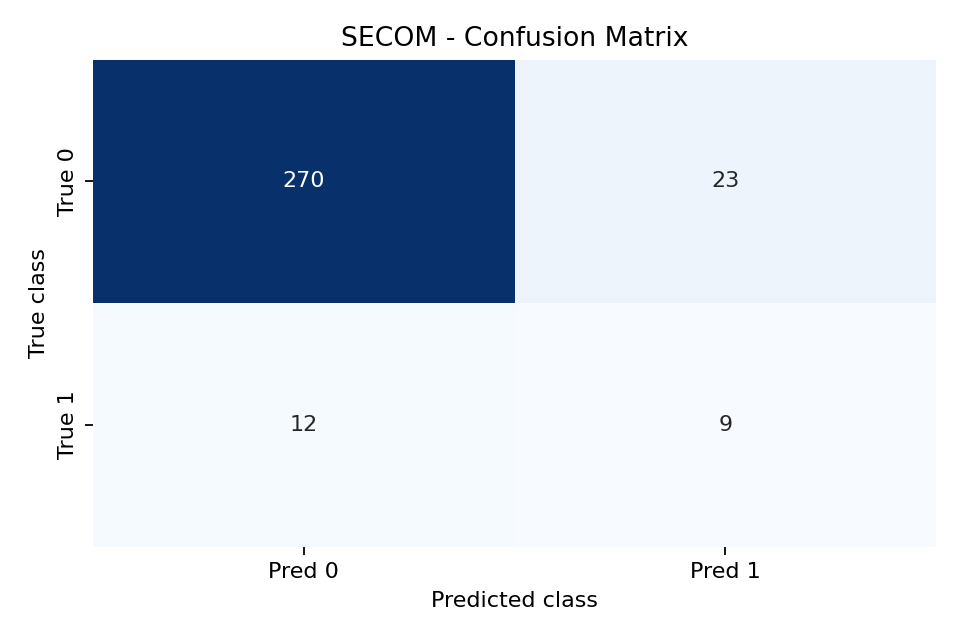


Sauvegarde des artefacts...
✓ Modèle sauvegardé: artifacts\secom_hgb_artifact.joblib
✓ Métriques sauvegardées: artifacts\secom_metrics.json
✓ Matrice sauvegardée: artifacts\secom_confusion_matrix.png

🎉 Pipeline terminé avec succès !


In [ ]:
# ============== ÉTAPE 1 : Charger et préparer les données ==============
df = load_data(DATA_PATH)
print(f"Dataset chargé : {df.shape[0]} échantillons, {df.shape[1]} colonnes brutes")

features, target = build_features(df)
print(f"Après ingénierie des features : {features.shape[1]} colonnes")
print(f"Distribution des classes : {target.value_counts().to_dict()}")

# Split stratifié : 65% train, 17.5% val, 17.5% test
x_train, x_val, x_test, y_train, y_val, y_test, imputer, scaler = prepare_data(features, target)
print(f"Train: {x_train.shape[0]}, Val: {x_val.shape[0]}, Test: {x_test.shape[0]}")

# ============== ÉTAPE 2 : Entraîner le modèle ==============
print("\nEntraînement du modèle...")
model = train_model(x_train, y_train)
print(f"Modèle entraîné. Nombre d'itérations : {model.n_iter_}")

# ============== ÉTAPE 3 : Choisir le seuil optimal ==============
print("\nSélection du seuil optimal...")
val_score = model.predict_proba(x_val)[:, 1]  # Probabilités sur validation
threshold = choose_threshold(y_val, val_score)
print(f"Seuil choisi : {threshold:.4f}")

# Vérifier que le rappel en validation est suffisant
y_val_pred = (val_score >= threshold).astype(int)
val_recall = recall_score(y_val, y_val_pred, zero_division=0)
print(f"Rappel en validation : {val_recall:.4f} (minimum requis: {MIN_VALIDATION_RECALL})")

# ============== ÉTAPE 4 : Évaluer sur test avec le seuil sélectionné ==============
print("\nÉvaluation sur l'ensemble de test...")
y_score = model.predict_proba(x_test)[:, 1]
y_pred = (y_score >= threshold).astype(int)
metrics = evaluate_model(model, x_test, y_test, threshold)
metrics['threshold'] = float(threshold)

# ============== ÉTAPE 5 : Affichage des résultats ==============
print('\n' + '='*50)
print('=== SECOM Predictive Maintenance - Résultats ===')
print('='*50)
print(f'Samples: {len(df)}')
print(f'Features after engineering: {features.shape[1]}')
print(f'Chosen threshold from validation: {threshold:.4f}')
print(f'Minimum validation recall target: {MIN_VALIDATION_RECALL:.2f}')
print('')
print('Classification report:')
print(classification_report(y_test, y_pred, digits=4, zero_division=0))
print('\nMétriques détaillées:')
print(json.dumps(metrics, indent=2, ensure_ascii=False))

# Affichage des métriques sous forme de tableau pour clarté
from IPython.display import Image, display

metrics_table = pd.DataFrame([metrics]).T
metrics_table.columns = ['Valeur']
print("\nRésumé des métriques:")
display(metrics_table)

# ============== ÉTAPE 6 : Sauvegarde et visualisation ==============
print("\nGénération et sauvegarde de la matrice de confusion...")
save_confusion_matrix(y_test, y_pred)
display(Image(filename=str(CONFUSION_MATRIX_PATH)))

# Sauvegarde du modèle entraîné pour réutilisation
print("\nSauvegarde des artefacts...")
joblib.dump(
    {
        'model': model,
        'imputer': imputer,
        'scaler': scaler,
        'feature_columns': list(features.columns),
        'threshold': float(threshold),
    },
    MODEL_PATH,
)

# Sauvegarde des métriques en JSON
with METRICS_PATH.open('w', encoding='utf-8') as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print(f'Modèle sauvegardé: {MODEL_PATH}')
print(f'Métriques sauvegardées: {METRICS_PATH}')
print(f'Matrice sauvegardée: {CONFUSION_MATRIX_PATH}')
print('\nPipeline terminé avec succès !')

## Résultats affichés dans le notebook

La cellule suivante affiche les métriques, le rapport de classification et la matrice de confusion directement dans le notebook afin que le rendu HTML montre les résultats comme après exécution.